# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('hotels.csv')

---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [3]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# this gives summary stats for the integer and float columns
print(df.describe())

         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                   38.000000            

In [5]:
# This gives a summary for all str columns
print(df.describe(include='str'))

             hotel arrival_date_month    meal country market_segment  \
count       119390             119390  119390  118902         119390   
unique           2                 12       5     177              8   
top     City Hotel             August      BB     PRT      Online TA   
freq         79330              13877   92310   48590          56477   

       distribution_channel reserved_room_type assigned_room_type  \
count                119390             119390             119390   
unique                    5                 10                 12   
top                   TA/TO                  A                  A   
freq                  97870              85994              74053   

       deposit_type customer_type reservation_status reservation_status_date  
count        119390        119390             119390                  119390  
unique            3             4                  3                     926  
top      No Deposit     Transient          Check-Out    

In [6]:
print(df.isna().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

I notice that there is a combination of str, float, and int columns. The dataset is pretty exhaustive and can tell you a bunch of different facets about the each reservation. For the summary statistics, some columns like lead time and days on the waiting list have a larger standard deviation than most of the other numeric columns which have a standard deviation of close to 1. Using days on the waiting list as an example, the mean is close to 2 with at least 75% of its values being 0 and the standard deviation is close to 18. This could indicate that outliers are present. Looking at the string columns that will be converted to categorical data, it seems like things like room type or customer type could potentially tell us a lot about whether someone will cancel with 12 different types of rooms and 4 different types of customers. Also, agent, company, children, and country have missing values so we will either have to drop those columns or rows depending on the situation. 

In [7]:
# Calculate prevalence of the target value, how hard of problem is this going to be?
print(f"The prevalence of the trarget value is: {df['is_canceled'].mean()}")

The prevalence of the trarget value is: 0.37041628277075134


It is not going to be a particularly hard problem because 37% of the outcomes end it a cancelation, while the other 63% do not cancel. This means that there is a good amount of data with both outcomes that the model can learn from. Of course, the best split would probably be something closer to 50/50, but 60/40 is pretty good.

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [8]:
# Check for missing data and drop features with too many missing values, there are some. 
print(df.isna().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
# the rows where country is NA need to be dropped 
# I don't want to cut out over 10% of the rows so I will remove the agent and company columns altogether

df.drop(columns=['agent', 'company'], inplace=True)
df.dropna(inplace = True)

In [10]:
# There are two other features that need to be dropped because they directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

df.drop(columns=["reservation_status"], inplace=True)

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  str    
 1   is_canceled                     118898 non-null  int64  
 2   lead_time                       118898 non-null  int64  
 3   arrival_date_year               118898 non-null  int64  
 4   arrival_date_month              118898 non-null  str    
 5   arrival_date_week_number        118898 non-null  int64  
 6   arrival_date_day_of_month       118898 non-null  int64  
 7   stays_in_weekend_nights         118898 non-null  int64  
 8   stays_in_week_nights            118898 non-null  int64  
 9   adults                          118898 non-null  int64  
 10  children                        118898 non-null  float64
 11  babies                          118898 non-null  int64  
 12  meal                            

In [12]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [13]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

TARGET = "is_canceled"
CATEGORICAL = ['hotel', 'meal', 'market_segment', 'distribution_channel',
               'reserved_room_type', 'assigned_room_type', 'deposit_type',
                'customer_type', 'reservation_status_date', 
                'is_repeated_guest', 'arrival_date_month'
                ]
NUMERICAL = ['lead_time', 'adr', 'children', 'arrival_date_year', 
             'arrival_date_week_number','arrival_date_day_of_month', 
             'stays_in_weekend_nights','stays_in_week_nights', 'adults', 'babies', 
             'previous_cancellations', 'previous_bookings_not_canceled', 
             'booking_changes','days_in_waiting_list', 'required_car_parking_spaces',
             'total_of_special_requests'  
             ]

X = df[CATEGORICAL + NUMERICAL]
y = df[TARGET]


In [14]:
X.isna().sum()

hotel                             0
meal                              0
market_segment                    0
distribution_channel              0
reserved_room_type                0
assigned_room_type                0
deposit_type                      0
customer_type                     0
reservation_status_date           0
is_repeated_guest                 0
arrival_date_month                0
lead_time                         0
adr                               0
children                          0
arrival_date_year                 0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
babies                            0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
days_in_waiting_list              0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [15]:
# Train / test split — 80/20, stratified so class ratios are preserved 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.2, random_state=42, stratify=y
    )

---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [16]:
# sklearn Pipeline: New Concept 
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(solver="lbfgs" , max_iter=5000, random_state=42))
])

pipe_m1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

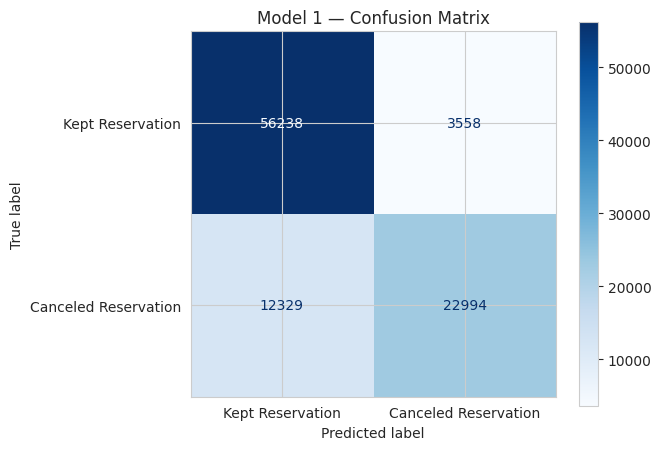

                      precision    recall  f1-score   support

    Kept Reservation       0.82      0.94      0.88     59796
Canceled Reservation       0.87      0.65      0.74     35323

            accuracy                           0.83     95119
           macro avg       0.84      0.80      0.81     95119
        weighted avg       0.84      0.83      0.83     95119



In [17]:
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Kept Reservation', 'Canceled Reservation'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Kept Reservation', 'Canceled Reservation']))

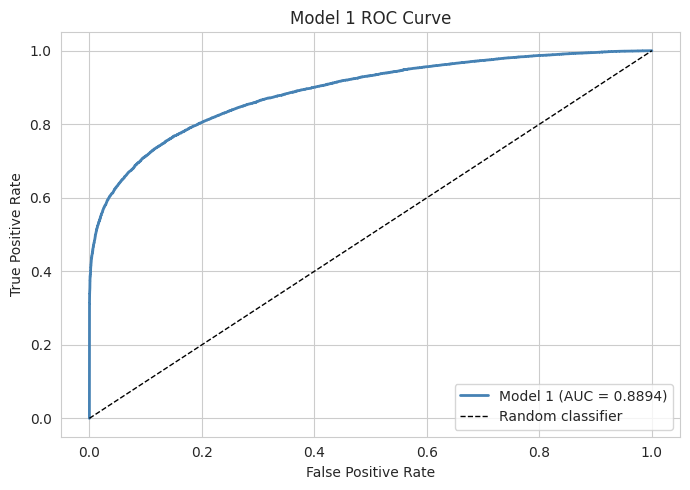

Model 1 ROC-AUC: 0.8894


In [18]:
y_proba_m1 = pipe_m1.predict_proba(X_test)[:,1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



In [19]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m2_lib = Pipeline(steps=[
    ('prep', preprocessor_m2),
    ('model', LogisticRegression(solver = 'liblinear' , max_iter=5000, random_state=42, l1_ratio=1))
])

pipe_m2_lib.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

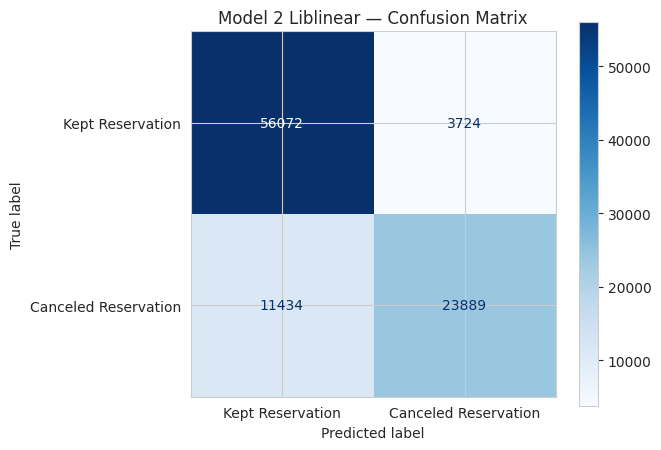

                      precision    recall  f1-score   support

    Kept Reservation       0.83      0.94      0.88     59796
Canceled Reservation       0.87      0.68      0.76     35323

            accuracy                           0.84     95119
           macro avg       0.85      0.81      0.82     95119
        weighted avg       0.84      0.84      0.84     95119



In [20]:

y_pred_m2_lib = pipe_m2_lib.predict(X_test)

cm_m2_lib = confusion_matrix(y_test, y_pred_m2_lib)

disp_m2_lib = ConfusionMatrixDisplay(confusion_matrix=cm_m2_lib, display_labels=['Kept Reservation', 'Canceled Reservation'])
disp_m2_lib.plot(cmap='Blues')
plt.title('Model 2 Liblinear — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_lib, target_names=['Kept Reservation', 'Canceled Reservation']))

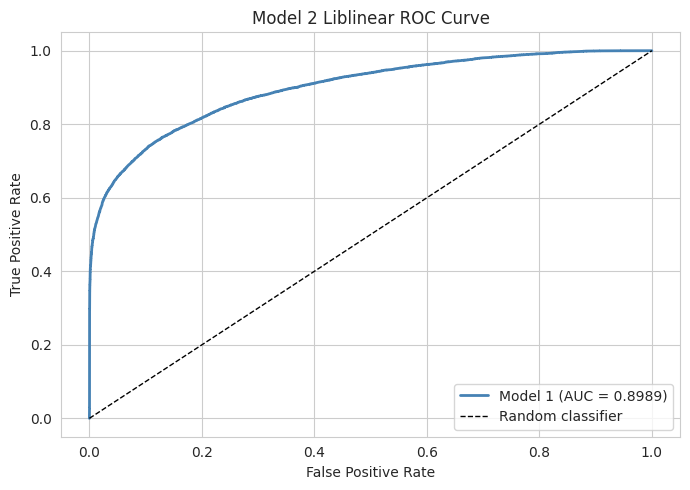

Model 2 Liblinear ROC-AUC: 0.8989


In [21]:
y_proba_m2_lib = pipe_m2_lib.predict_proba(X_test)[:,1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m2_lib)
auc_m1 = roc_auc_score(y_test, y_proba_m2_lib)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 Liblinear ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 Liblinear ROC-AUC: {auc_m1:.4f}")

In [22]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m2_saga = Pipeline(steps=[
    ('prep', preprocessor_m2),
    ('model', LogisticRegression(solver = 'saga' , max_iter=5000, random_state=42, l1_ratio=1))
])

pipe_m2_saga.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

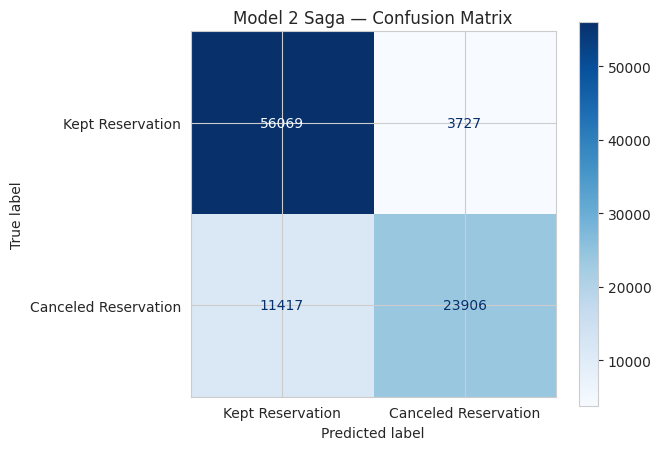

                      precision    recall  f1-score   support

    Kept Reservation       0.83      0.94      0.88     59796
Canceled Reservation       0.87      0.68      0.76     35323

            accuracy                           0.84     95119
           macro avg       0.85      0.81      0.82     95119
        weighted avg       0.84      0.84      0.84     95119



In [23]:
y_pred_m2_saga= pipe_m2_saga.predict(X_test)

cm_m2_saga = confusion_matrix(y_test, y_pred_m2_saga)

disp_m2_saga = ConfusionMatrixDisplay(confusion_matrix=cm_m2_saga, display_labels=['Kept Reservation', 'Canceled Reservation'])
disp_m2_saga.plot(cmap='Blues')
plt.title('Model 2 Saga — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_saga, target_names=['Kept Reservation', 'Canceled Reservation']))

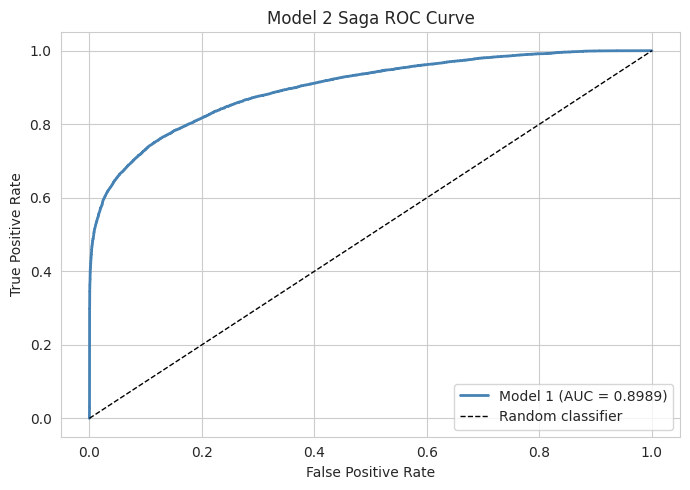

Model 2 Saga ROC-AUC: 0.8989


In [24]:
y_proba_m2_saga = pipe_m2_saga.predict_proba(X_test)[:,1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m2_saga)
auc_m1 = roc_auc_score(y_test, y_proba_m2_saga)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 Saga ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 Saga ROC-AUC: {auc_m1:.4f}")

Looking at the AUC and Confusion Matrix for all of the models, there is not much of a difference in performance, between the saga and liblinear solver, but both of those solvers do better than the lbfgs model. This is shown by a higher precision in the cancelation category and an increases AUC. The consistent recall means the models performed just as well at catching the real cancelations and increased precision means that the models in part 2 had a higher %-age of their predictied cancelations to be actual cancelations. Also, the AUC increasing shows that the models in part 2 are more robust. Part of me thinks that I might need to adjust the l1_ratio to better improve performance but I am unsure of that and the question did not ask me to do that. Additiona

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

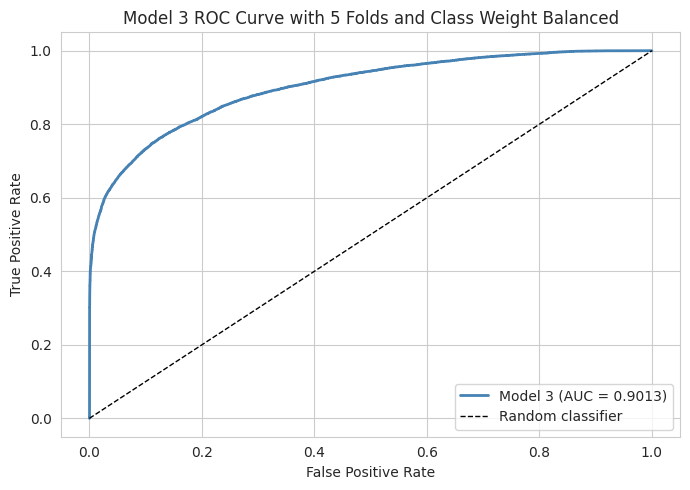

Model 3 ROC-AUC: 0.9013
                      precision    recall  f1-score   support

    Kept Reservation       0.87      0.86      0.86     59796
Canceled Reservation       0.76      0.78      0.77     35323

            accuracy                           0.83     95119
           macro avg       0.82      0.82      0.82     95119
        weighted avg       0.83      0.83      0.83     95119



In [25]:
# with folds 5 and class weight balanced
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m3 = Pipeline(steps=[
    ('prep', preprocessor_m3),
    ('model', LogisticRegression(solver = 'liblinear' , max_iter=5000, random_state=42, l1_ratio=1, class_weight='balanced'))
])

cv_scores = cross_val_score(pipe_m3, X_train, y_train, cv=5, scoring='accuracy')

pipe_m3.fit(X_train,y_train)

y_pred_m3= pipe_m3.predict(X_test)

y_proba_m3 = pipe_m3.predict_proba(X_test)[:,1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m3)
auc_m1 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve with 5 Folds and Class Weight Balanced')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m1:.4f}")
print(classification_report(y_test, y_pred_m3, target_names=['Kept Reservation', 'Canceled Reservation']))


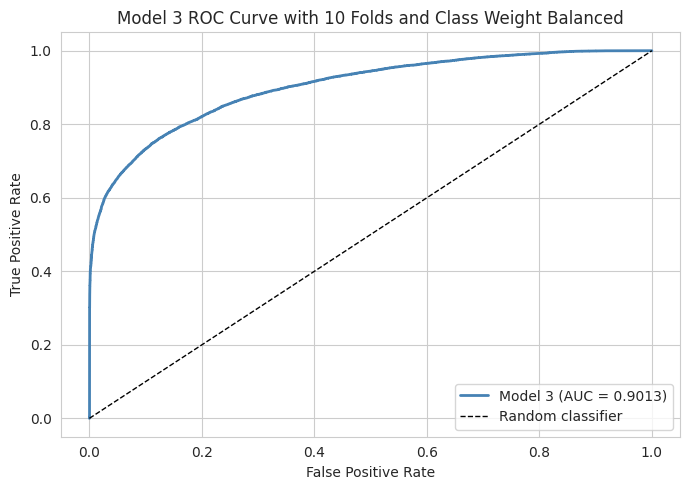

Model 3 ROC-AUC: 0.9013
                      precision    recall  f1-score   support

    Kept Reservation       0.87      0.86      0.86     59796
Canceled Reservation       0.76      0.78      0.77     35323

            accuracy                           0.83     95119
           macro avg       0.82      0.82      0.82     95119
        weighted avg       0.83      0.83      0.83     95119



In [26]:
# with folds 10 folds and class weight balanced
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m3 = Pipeline(steps=[
    ('prep', preprocessor_m3),
    ('model', LogisticRegression(solver = 'liblinear' , max_iter=5000, random_state=42, l1_ratio=1, class_weight='balanced'))
])

cv_scores = cross_val_score(pipe_m3, X_train, y_train, cv=10, scoring='accuracy')

pipe_m3.fit(X_train,y_train)

y_pred_m3= pipe_m3.predict(X_test)

y_proba_m3 = pipe_m3.predict_proba(X_test)[:,1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m3)
auc_m1 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve with 10 Folds and Class Weight Balanced')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m1:.4f}")
print(classification_report(y_test, y_pred_m3, target_names=['Kept Reservation', 'Canceled Reservation']))

When changing the number of folds from 5 to 10 there is no change in the AUC.

In [27]:
# with folds 5 and without class weight balanced
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m3 = Pipeline(steps=[
    ('prep', preprocessor_m3),
    ('model', LogisticRegression(solver = 'liblinear' , max_iter=5000, random_state=42, l1_ratio=1, class_weight=None))
])

cv_scores = cross_val_score(pipe_m3, X_train, y_train, cv=5, scoring='accuracy')

pipe_m3.fit(X_train,y_train)

y_pred_m3= pipe_m3.predict(X_test)

print(classification_report(y_test, y_pred_m3, target_names=['Kept Reservation', 'Canceled Reservation']))


                      precision    recall  f1-score   support

    Kept Reservation       0.83      0.94      0.88     59796
Canceled Reservation       0.87      0.68      0.76     35323

            accuracy                           0.84     95119
           macro avg       0.85      0.81      0.82     95119
        weighted avg       0.84      0.84      0.84     95119



In [30]:
# with folds 10 and without class weight balanced
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERICAL),

])

pipe_m3 = Pipeline(steps=[
    ('prep', preprocessor_m3),
    ('model', LogisticRegression(solver = 'liblinear' , max_iter=5000, random_state=42, l1_ratio=1, class_weight=None))
])

cv_recall_scores = cross_val_score(pipe_m3, X_train, y_train, cv=10, scoring='recall')

pipe_m3.fit(X_train,y_train)

y_pred_m3= pipe_m3.predict(X_test)

print(classification_report(y_test, y_pred_m3, target_names=['Kept Reservation', 'Canceled Reservation']))

                      precision    recall  f1-score   support

    Kept Reservation       0.83      0.94      0.88     59796
Canceled Reservation       0.87      0.68      0.76     35323

            accuracy                           0.84     95119
           macro avg       0.85      0.81      0.82     95119
        weighted avg       0.84      0.84      0.84     95119



There is no difference between 5-fold and 10-fold, but the recall is 0.68 without class weight balanced and recall is 0.78 with class weight balanced. This is the recall value for canceled reservations. We should include class weight balance in our final model.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

The model that worked best in this case is a logistic regression model with a liblinear solver, 5-fold, l1_ratio = 1, and where class_weight is balanced. Our goal is to ensure that we have a model that catches the highest percentage of canceled reservations. As long as all canceled reservations are caught, we don't care if the model mistakenly identifies some reservations as potential cancelations despite them not cancelling. This means, we want a model that is robuts (highest AUC), and with the highest recall percentage. The liblinear and saga solvers performed better than the lbfgs models because the recall value for cancellations was higher. Despite both liblinear and saga solvers performing the same, it is best to choose the liblinear solver in this case since it is made for smaller datasets and requires less computing time/power. I recommend a 5-fold crossvalidation in comparison to a 10-fold for a similar reason. In both scenarios, the recall score and AUC (robustness of the model) are the same, but 5-fold requires less computing power. Utilizing the l1_ratio = 1, we will be able to ensure that we get the most accurate predictions while also removing coefficients that are unimportant to the overall performance of the model, again reducing computing power and increasing accuracy. Finally, the model should have class weights be balanced so that the minority class, cancelations (our target class), gets equal attention while training the model. This significantly improves our recall score. In the end, the model chosen is very robust with an AUC of 0.9, and a recall of 0.78. This means we will catch cancellations 78% of the time with this model. There is definitely room for improvement, but that is a potential retention of 78% of the cancellations that you were not able to identify before.